## Import Libraries

In [325]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch import nn
from sklearn.preprocessing import MinMaxScaler


## Setup device agnostic code

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

## Import dataset

In [327]:
# Import csv file 
df = pd.read_csv('ADANIPORTS.csv',index_col='Date', parse_dates=True)

## Check head, shape, info

In [328]:
df.head()

,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
Date,,,,,,,,,,,,,,
2007-11-27,MUNDRAPORT,EQ,440.00,770.00,1050.00,770.0,959.0,962.90,984.72,27294366,2.687719e+15,NaN,9859619,0.3612
2007-11-28,MUNDRAPORT,EQ,962.90,984.00,990.00,874.0,885.0,893.90,941.38,4581338,4.312765e+14,NaN,1453278,0.3172
2007-11-29,MUNDRAPORT,EQ,893.90,909.00,914.75,841.0,887.0,884.20,888.09,5124121,4.550658e+14,NaN,1069678,0.2088
2007-11-30,MUNDRAPORT,EQ,884.20,890.00,958.00,890.0,929.0,921.55,929.17,4609762,4.283257e+14,NaN,1260913,0.2735
2007-12-03,MUNDRAPORT,EQ,921.55,939.75,995.00,922.0,980.0,969.30,965.65,2977470,2.875200e+14,NaN,816123,0.2741


In [329]:
df.shape

(3322, 14)

In [359]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 3322 entries, 2007-11-27 to 2021-04-30
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Symbol              3322 non-null   str    
 1   Series              3322 non-null   str    
 2   Prev Close          3322 non-null   float64
 3   Open                3322 non-null   float64
 4   High                3322 non-null   float64
 5   Low                 3322 non-null   float64
 6   Last                3322 non-null   float64
 7   Close               3322 non-null   float64
 8   VWAP                3322 non-null   float64
 9   Volume              3322 non-null   int64  
 10  Turnover            3322 non-null   float64
 11  Trades              2456 non-null   float64
 12  Deliverable Volume  3322 non-null   int64  
 13  %Deliverble         3322 non-null   float64
dtypes: float64(10), int64(2), str(2)
memory usage: 389.3 KB


## Check for missing , Duplicated values..

<Axes: ylabel='Date'>

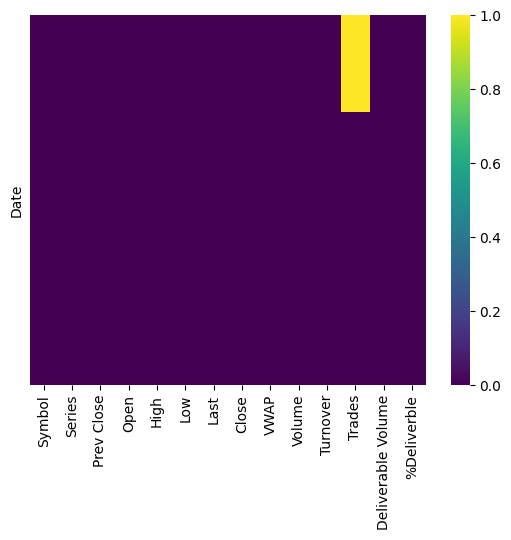

In [330]:
sns.heatmap(df.isnull(), cbar=True, cmap='viridis',yticklabels=False)

In [331]:
df.Trades.isnull().sum() # 866 values are missing

np.int64(866)

In [332]:
df.duplicated().sum() # No duplicated values exists

np.int64(0)

## Keep only numeric columns

In [ ]:

numeric_df = df.drop(['Symbol','Series','%Deliverble'], axis=1)
numeric_df.head()

,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume
Date,,,,,,,,,,,
2007-11-27,440.00,770.00,1050.00,770.0,959.0,962.90,984.72,27294366,2.687719e+15,NaN,9859619
2007-11-28,962.90,984.00,990.00,874.0,885.0,893.90,941.38,4581338,4.312765e+14,NaN,1453278
2007-11-29,893.90,909.00,914.75,841.0,887.0,884.20,888.09,5124121,4.550658e+14,NaN,1069678
2007-11-30,884.20,890.00,958.00,890.0,929.0,921.55,929.17,4609762,4.283257e+14,NaN,1260913
2007-12-03,921.55,939.75,995.00,922.0,980.0,969.30,965.65,2977470,2.875200e+14,NaN,816123


## Interpolate the missing values

In [ ]:
numeric_df['Trades']= numeric_df['Trades'].interpolate(method='linear',limit_direction='both')
numeric_df['Trades'] = numeric_df['Trades'].ffill().bfill()

In [336]:
numeric_df.head()

,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume
Date,,,,,,,,,,,
2007-11-27,440.00,770.00,1050.00,770.0,959.0,962.90,984.72,27294366,2.687719e+15,19171.0,9859619
2007-11-28,962.90,984.00,990.00,874.0,885.0,893.90,941.38,4581338,4.312765e+14,19171.0,1453278
2007-11-29,893.90,909.00,914.75,841.0,887.0,884.20,888.09,5124121,4.550658e+14,19171.0,1069678
2007-11-30,884.20,890.00,958.00,890.0,929.0,921.55,929.17,4609762,4.283257e+14,19171.0,1260913
2007-12-03,921.55,939.75,995.00,922.0,980.0,969.30,965.65,2977470,2.875200e+14,19171.0,816123


<Axes: ylabel='Date'>

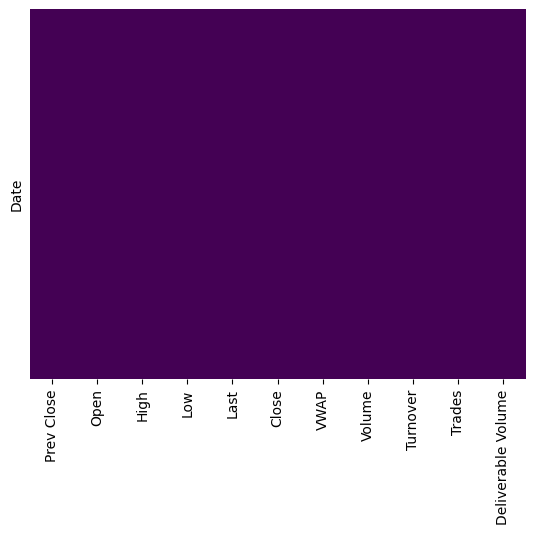

In [ ]:
# check again for the null values using Heatmap
sns.heatmap(numeric_df.isnull(), cbar=False, cmap='viridis',yticklabels=False)

In [ ]:
# Features Used 
features_names = numeric_df.columns.tolist()
features_names 

['Prev Close',
 'Open',
 'High',
 'Low',
 'Last',
 'Close',
 'VWAP',
 'Volume',
 'Turnover',
 'Trades',
 'Deliverable Volume']

## Visualize the Time Series

In [ ]:
# Create Function for plotting the relation between the timeseries(date) and features 
def pred_plot(feature_name):
    plt.figure(figsize=(10, 6))

    plt.plot(numeric_df.index, numeric_df[feature_name], label=feature_name) # Col= CO(GT)
    
    plt.title(f'Adani_stock/ Time-index vs {feature_name}')
    plt.xlabel('Date Index')
    plt.ylabel(feature_name)
    plt.legend()
    plt.show()

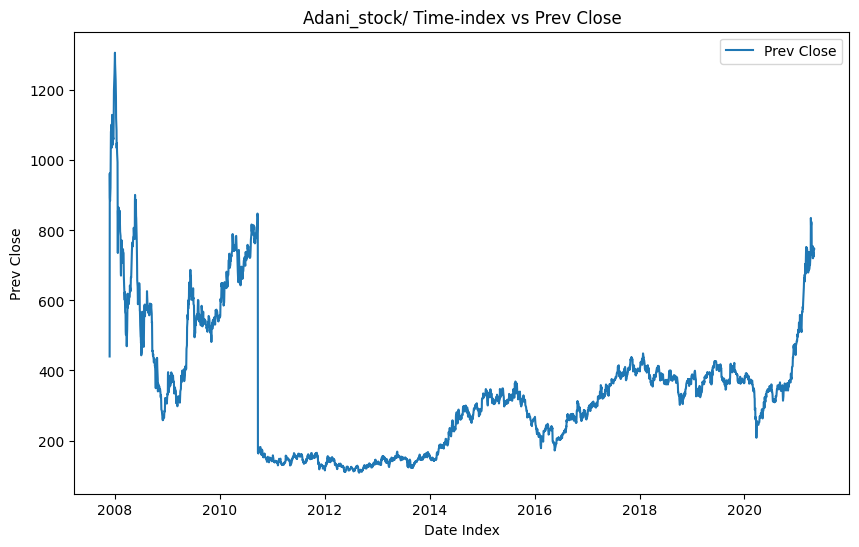

In [341]:
pred_plot('Prev Close')

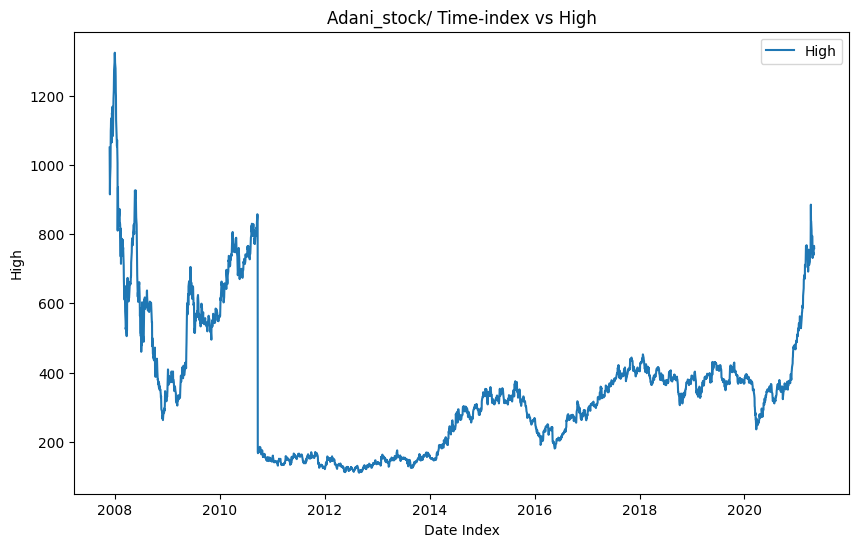

In [342]:
pred_plot(feature_name='High')

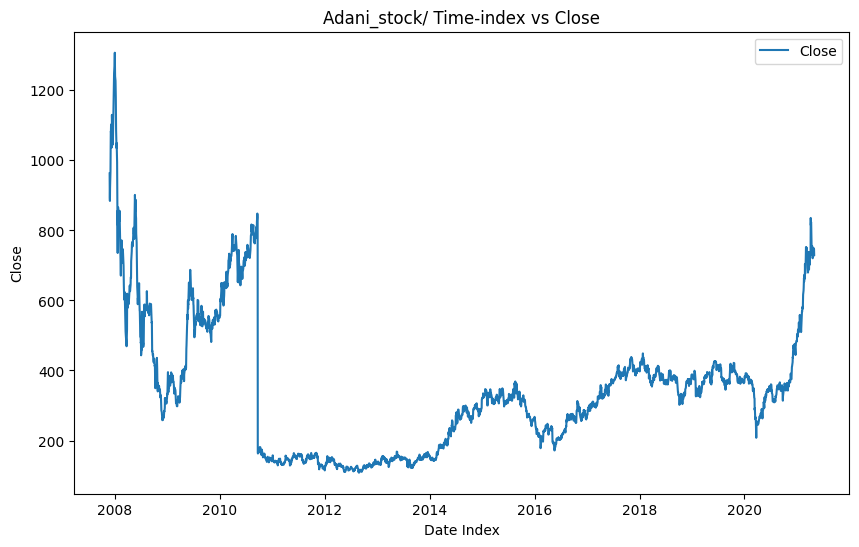

In [343]:
pred_plot(feature_name='Close')

In [ ]:
# create numpy array of values with dtype=float32
data = numeric_df.values.astype(np.float32)

(3322, 11)

## Set up some Hyperparameter

In [345]:
input_steps =10
output_steps = 5
train_ratio = 0.8
batch_size = 4

## Train-Test Split

In [346]:
# train_test split into 80:20
# with train further split into tarin and validation sets

split_idx = int(len(data) * train_ratio)
train_data = data[:split_idx]
test_data = data[split_idx:]

## Noramlize (fit on the train only)

In [347]:
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_data).astype(np.float32)
test_scaled = scaler.transform(test_data).astype(np.float32)

## Sliding window chunking

In [348]:
# input_steps =10
# output_steps = 5
# train_ratio = 0.8
# batch_size = 4

# input_ steps: number of past time steps used as input =10
# output_steps: number of future time steps to predict =5

def create_sequences(data_array, input_steps=10, output_steps=5, overlap=1):
    X, y = [],[]
    total_len = len(data_array)

    stride = input_steps - overlap

    if stride<=0:
        raise ValueError("Overlap must be smaller than input steps")
    
    for i in range(0 , total_len - input_steps - output_steps + 1, stride):
        X.append(data_array[i:i + input_steps])
        y.append(data_array[i + input_steps:i + input_steps + output_steps])
    
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

### Preparing train and test data with chunking

In [349]:
# preparing train/test data with chunking

X_train, y_train = create_sequences(train_scaled, overlap=5)
X_test, y_test = create_sequences(test_scaled, overlap=5)

print("X_train: ",X_train.shape, " y_train: ",y_train.shape)
print("X_test: ",X_test.shape, " y_test: ",y_test.shape)


X_train:  (529, 10, 11)  y_train:  (529, 5, 11)
X_test:  (131, 10, 11)  y_test:  (131, 5, 11)


In [350]:
# create custom dataset 
from torch.utils.data import Dataset, DataLoader
class TimeSeriesdataset(Dataset):
    def __init__(self,X, y):
        self.X =  torch.tensor(X, dtype=torch.float32)
        self.y =  torch.tensor(y, dtype=torch.float32)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, index):
        return self.X[index], self.y[index]
        

## define Tensor dataset and dataloader

In [351]:
train_dataset = TimeSeriesdataset(X_train, y_train)
test_dataset = TimeSeriesdataset(X_test, y_test)


train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
# (batch_size, seq_len, features)

## LSTM Model

In [352]:
class LSTMforecaster(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(11, 10,batch_first=True)
        self.fc = nn.Linear(10, 5*11)
    
    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out.view(-1,5,11)
    

# An LSTM in PyTorch returns two things:
# output, (hidden_state, cell_state) or Stm vs ltm

# output shape = (batch_size, input_shape, hidden_size)

### Train

In [353]:
# Instantiate model with a  scheduler, opyimizer and criterion

model = LSTMforecaster().to(device)
lr= 0.0001
optimizer = torch.optim.Adam(model.parameters(), lr =lr)
criterion = nn.MSELoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10)


In [354]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss =0.0

    for X_batch , y_batch in loader:
         X_batch = X_batch.to(device)
         y_batch= y_batch.to(device)

         optimizer.zero_grad()
         preds = model(X_batch)
         loss = criterion(preds, y_batch) 
         loss.backward()
         optimizer.step()

         running_loss += loss.item() * X_batch.size(0)
    

    return running_loss/ len(loader.dataset)

## Test

In [355]:
def evaluate(model, loader, criterion,device):
    model.eval()
    running_loss = 0.0

    all_preds = []
    all_targets = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            preds = model(X_batch)
            loss = criterion(preds, y_batch)

            running_loss += loss.item() * X_batch.size(0) # MSE

            all_preds.append(preds.cpu())
            all_targets.append(y_batch.cpu())

    mse = running_loss / len(loader.dataset)
    rmse = np.sqrt(mse)

    all_preds = torch.cat(all_preds, dim=0).numpy()
    all_targets = torch.cat(all_targets, dim=0).numpy()

    # flatten
    y_pred_flat = all_preds.reshape(-1)
    y_true_flat = all_targets.reshape(-1)
    mae = np.mean(np.abs(y_pred_flat - y_true_flat))

    return mse, rmse, mae, all_preds, all_targets

In [356]:
# One simple training 

EPOCHS = 30
train_losses = []
test_losses = []

for epoch in range(EPOCHS):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    test_loss,_,_,_,_= evaluate(model, test_loader, criterion, device)

    train_losses.append(train_loss)
    test_losses.append(test_loss)

    print(f"Epoch [{epoch+1}/{EPOCHS} | Train Loss: {train_loss:.6f}  |  Test Loss: {test_loss:.6f}]")

Epoch [1/30 | Train Loss: 0.077405  |  Test Loss: 0.101464]
Epoch [2/30 | Train Loss: 0.067081  |  Test Loss: 0.090459]
Epoch [3/30 | Train Loss: 0.057124  |  Test Loss: 0.078713]
Epoch [4/30 | Train Loss: 0.046470  |  Test Loss: 0.065893]
Epoch [5/30 | Train Loss: 0.036064  |  Test Loss: 0.054651]
Epoch [6/30 | Train Loss: 0.027727  |  Test Loss: 0.045963]
Epoch [7/30 | Train Loss: 0.021771  |  Test Loss: 0.039916]
Epoch [8/30 | Train Loss: 0.017524  |  Test Loss: 0.035600]
Epoch [9/30 | Train Loss: 0.014418  |  Test Loss: 0.032711]
Epoch [10/30 | Train Loss: 0.012153  |  Test Loss: 0.030488]
Epoch [11/30 | Train Loss: 0.010470  |  Test Loss: 0.028884]
Epoch [12/30 | Train Loss: 0.009202  |  Test Loss: 0.027986]
Epoch [13/30 | Train Loss: 0.008251  |  Test Loss: 0.027344]
Epoch [14/30 | Train Loss: 0.007474  |  Test Loss: 0.026949]
Epoch [15/30 | Train Loss: 0.006840  |  Test Loss: 0.026501]
Epoch [16/30 | Train Loss: 0.006293  |  Test Loss: 0.026259]
Epoch [17/30 | Train Loss: 0.0058

## Evaluate the model

In [ ]:
mse, rmse, mae, predictions, targets = evaluate(model, test_loader, criterion, device)
print(f"MSE: {test_loss} | RMSE: {rmse}  |  MAE: {mae}")

MSE: 0.024553250838675402 | RMSE: 0.15669476965960097  |  MAE: 0.050965290516614914


## Plot Predictions vs True labels on test datasets

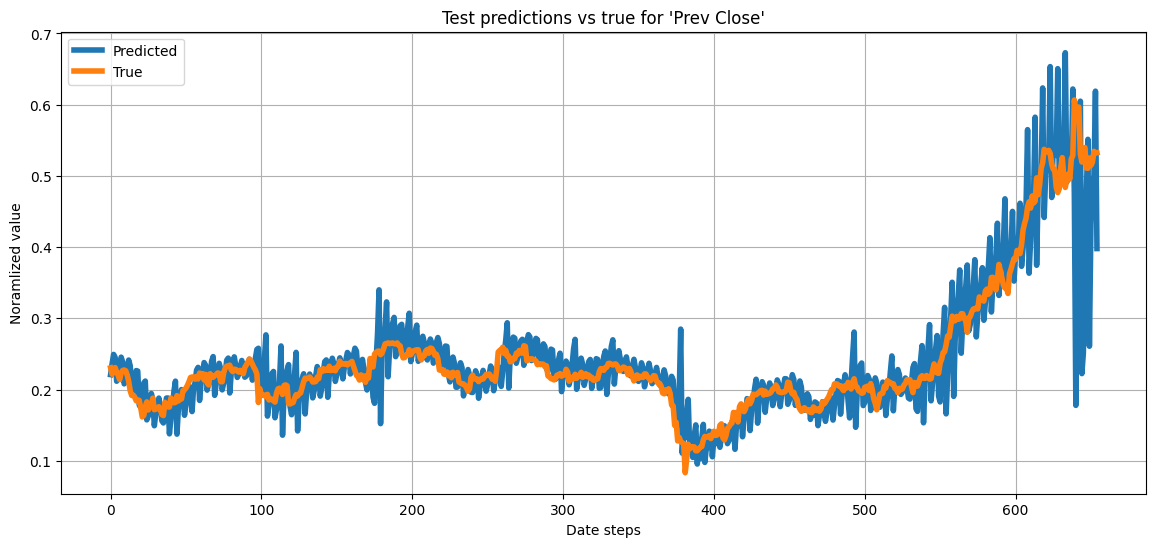

In [367]:
PLOT_FEATURE = "Prev Close"

if PLOT_FEATURE not in features_names:
    raise ValueError(f"{PLOT_FEATURE} not found, Choose from {features_names}")

feature_idx = features_names.index(PLOT_FEATURE)
pred_feature = predictions[:,:,feature_idx].reshape(-1)
true_feature = targets[:,:,feature_idx].reshape(-1)

plt.figure(figsize=(14,6))
plt.plot(pred_feature, lw=4, label="Predicted")
plt.plot(true_feature, lw=4,label="True")
plt.title(f"Test predictions vs true for '{PLOT_FEATURE}'")
plt.xlabel("Date steps")
plt.ylabel("Noramlized value")
plt.legend()
plt.grid(True)
plt.show()